In [160]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, mean_absolute_error
import xgboost as xgb
from sklearn.model_selection import train_test_split
import lightgbm as lgb
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.optim as optim

sns.set_theme(style="whitegrid")

In [161]:
core_stocks = ["aapl", "msft", "googl", "amzn", "nvda", "jpm", "bac", "gs", "xom", "gld", "jnj", "ko"]  
data_path = "Data_clean/Stocks clean"
sp500_path = "Data_clean/ETF clean/spy_clean.csv"
combined_df = pd.DataFrame()

In [162]:
for ticker in core_stocks:
    file_path = os.path.join(data_path, f"{ticker}_clean.csv")
    temp_df = pd.read_csv(file_path, index_col = "Date", parse_dates=True)
    combined_df[ticker] = temp_df["Close"]

sp500_df = pd.read_csv(sp500_path, index_col = "Date", parse_dates = True)

df = combined_df.copy()
df["spy"] = sp500_df["Close"]



In [163]:
df = df.sort_index()
start_date = '2010-01-01'
df = df.loc[start_date:]
df.head()

,aapl,msft,googl,amzn,nvda,jpm,bac,gs,xom,gld,jnj,ko,spy
Date,,,,,,,,,,,,,
2010-01-01,27.197,25.7575,311.685,134.21,17.243,35.2205,14.4935,155.925,55.5795,108.555,52.5315,23.2555,97.898
2010-01-04,27.406,25.9540,313.380,133.90,17.154,35.7110,14.7900,157.870,55.9680,109.800,52.6410,23.2630,98.728
2010-01-05,27.454,25.9630,312.000,134.69,17.406,36.4040,15.2750,160.660,56.1880,109.700,52.0300,22.9830,98.986
2010-01-06,27.017,25.8030,304.130,132.25,17.519,36.6030,15.4530,158.940,56.6750,111.510,52.4520,22.9740,99.040
2010-01-07,26.968,25.5350,297.050,130.00,17.172,37.3290,15.9610,162.040,56.4970,110.820,52.0780,22.9180,99.478


In [164]:
returns_df = df[core_stocks].pct_change()
returns_df['spy'] = df['spy'].pct_change().shift(-1)
returns_df = returns_df.loc["2010-01-02":]
returns_df = returns_df.dropna()
returns_df.head()

,aapl,msft,googl,amzn,nvda,jpm,bac,gs,xom,gld,jnj,ko,spy
Date,,,,,,,,,,,,,
2010-01-04,0.007685,0.007629,0.005438,-0.002310,-0.005162,0.013927,0.020457,0.012474,0.006990,0.011469,0.002084,0.000323,0.002613
2010-01-05,0.001751,0.000347,-0.004404,0.005900,0.014690,0.019406,0.032792,0.017673,0.003931,-0.000911,-0.011607,-0.012036,0.000546
2010-01-06,-0.015918,-0.006163,-0.025224,-0.018116,0.006492,0.005466,0.011653,-0.010706,0.008667,0.016500,0.008111,-0.000392,0.004422
2010-01-07,-0.001814,-0.010386,-0.023280,-0.017013,-0.019807,0.019834,0.032874,0.019504,-0.003141,-0.006188,-0.007130,-0.002438,0.003337
2010-01-08,0.006637,0.006932,0.013331,0.027077,0.002271,-0.002384,-0.008897,-0.018946,-0.004018,0.004963,0.003476,-0.018544,0.001403


In [165]:
X = returns_df[core_stocks]
y = returns_df["spy"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, shuffle = False)

In [166]:
model = xgb.XGBRegressor(n_estimators = 100, learning_rate = 0.05, max_depth = 3, random_state = 42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae}")

Mean Absolute Error: 0.00377624948152137


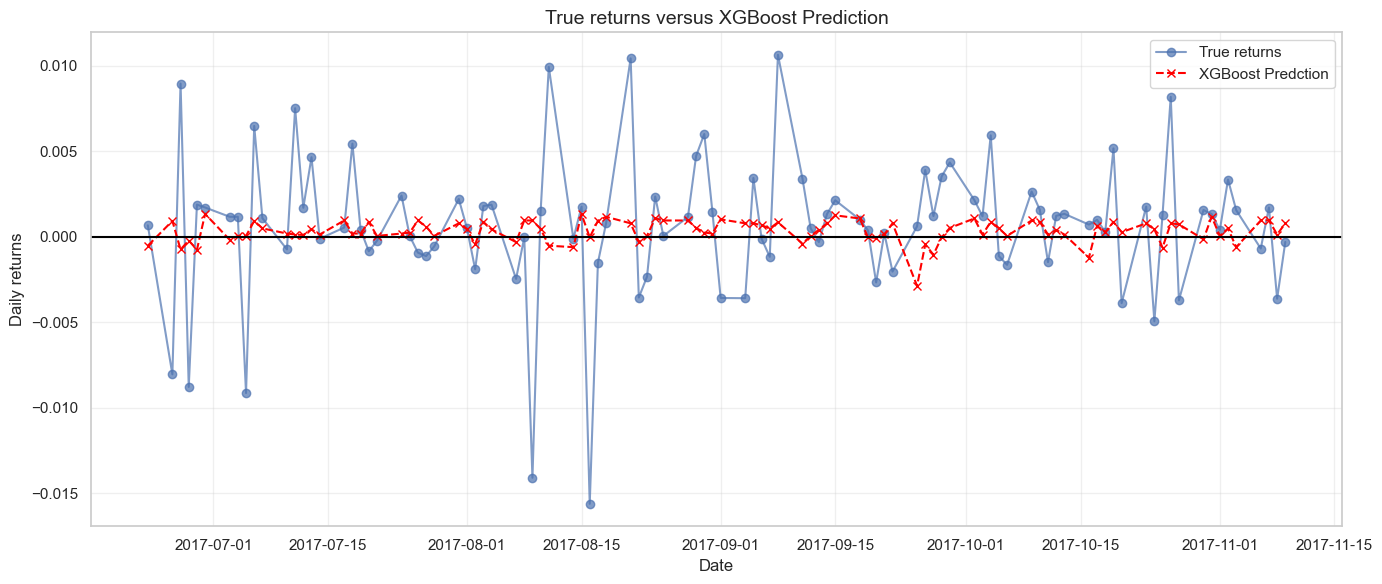

In [167]:
plt.figure(figsize=(14, 6))
last_days = 100
plt.plot(y_test.index[-last_days:], y_test.iloc[-last_days:], 
         label='True returns', marker='o', alpha=0.7)
plt.plot(y_test.index[-last_days:], y_pred[-last_days:], 
         label='XGBoost Predction', marker='x', linestyle='--', color='red')
plt.title('True returns versus XGBoost Prediction', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily returns', fontsize=12)
plt.axhline(0, color='black', linewidth=1.5, linestyle='-') 

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

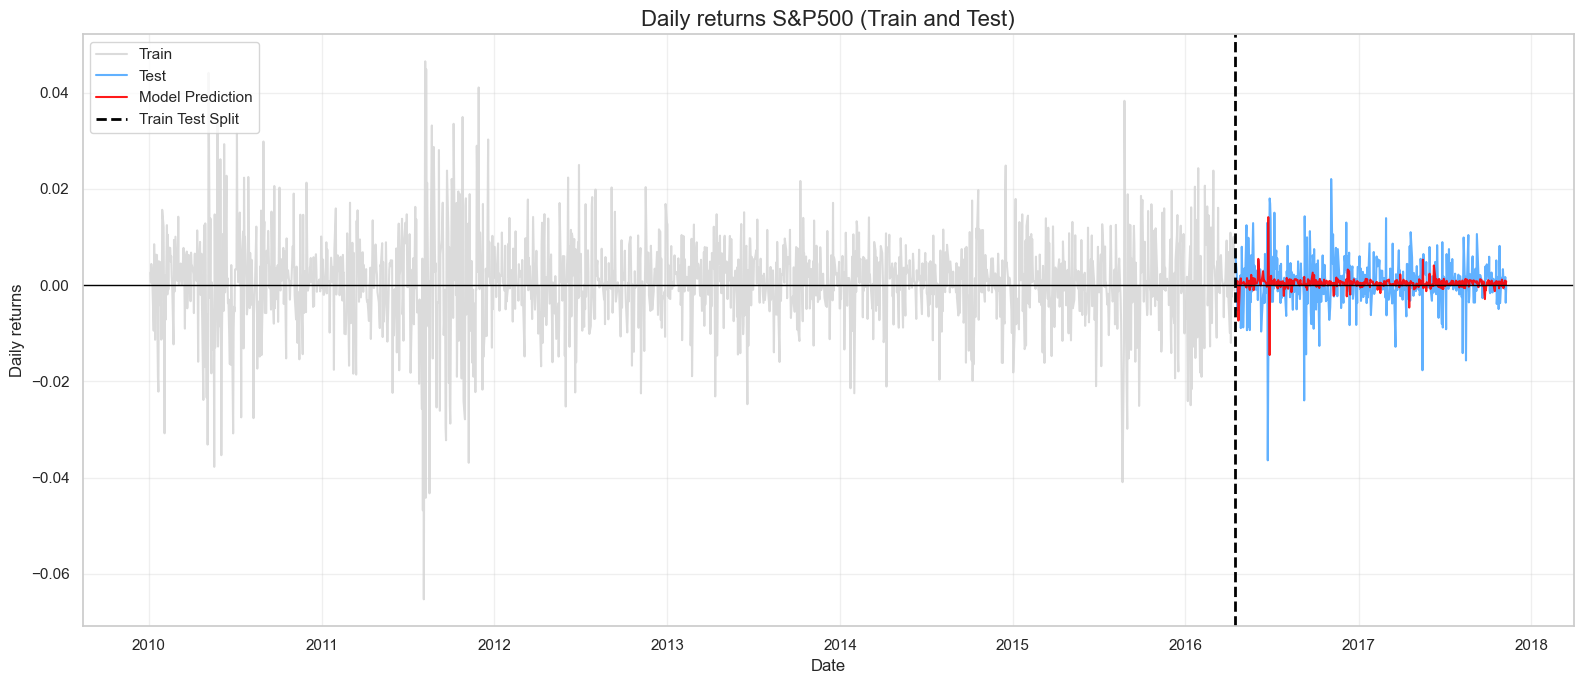

In [168]:
plt.figure(figsize=(16, 7))
plt.plot(y_train.index, y_train, label='Train', color='lightgray', alpha=0.8)
plt.plot(y_test.index, y_test, label='Test', color='dodgerblue', alpha=0.7)
plt.plot(y_test.index, y_pred, label='Model Prediction', color='red', alpha=0.9, linewidth=1.5)
plt.axvline(x=y_test.index[0], color='black', linestyle='--', linewidth=2, label='Train Test Split')
plt.axhline(0, color='black', linewidth=1)
plt.title('Daily returns S&P500 (Train and Test)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily returns', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [169]:
model = lgb.LGBMRegressor(n_estimators = 100, learning_rate = 0.05, num_leaves = 8, max_depth = 3, random_state = 42, verbose = -1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae}")

Mean Absolute Error: 0.003823004875650297


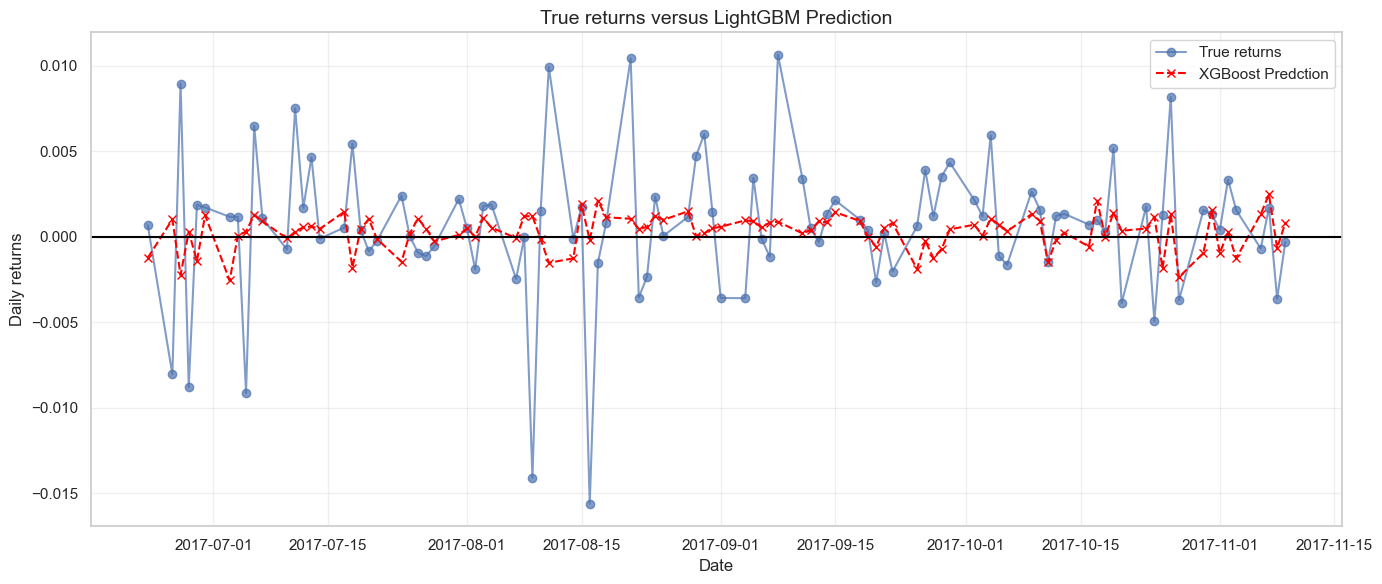

In [170]:
plt.figure(figsize=(14, 6))
last_days = 100
plt.plot(y_test.index[-last_days:], y_test.iloc[-last_days:], 
         label='True returns', marker='o', alpha=0.7)
plt.plot(y_test.index[-last_days:], y_pred[-last_days:], 
         label='XGBoost Predction', marker='x', linestyle='--', color='red')
plt.title('True returns versus LightGBM Prediction', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily returns', fontsize=12)
plt.axhline(0, color='black', linewidth=1.5, linestyle='-') 

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

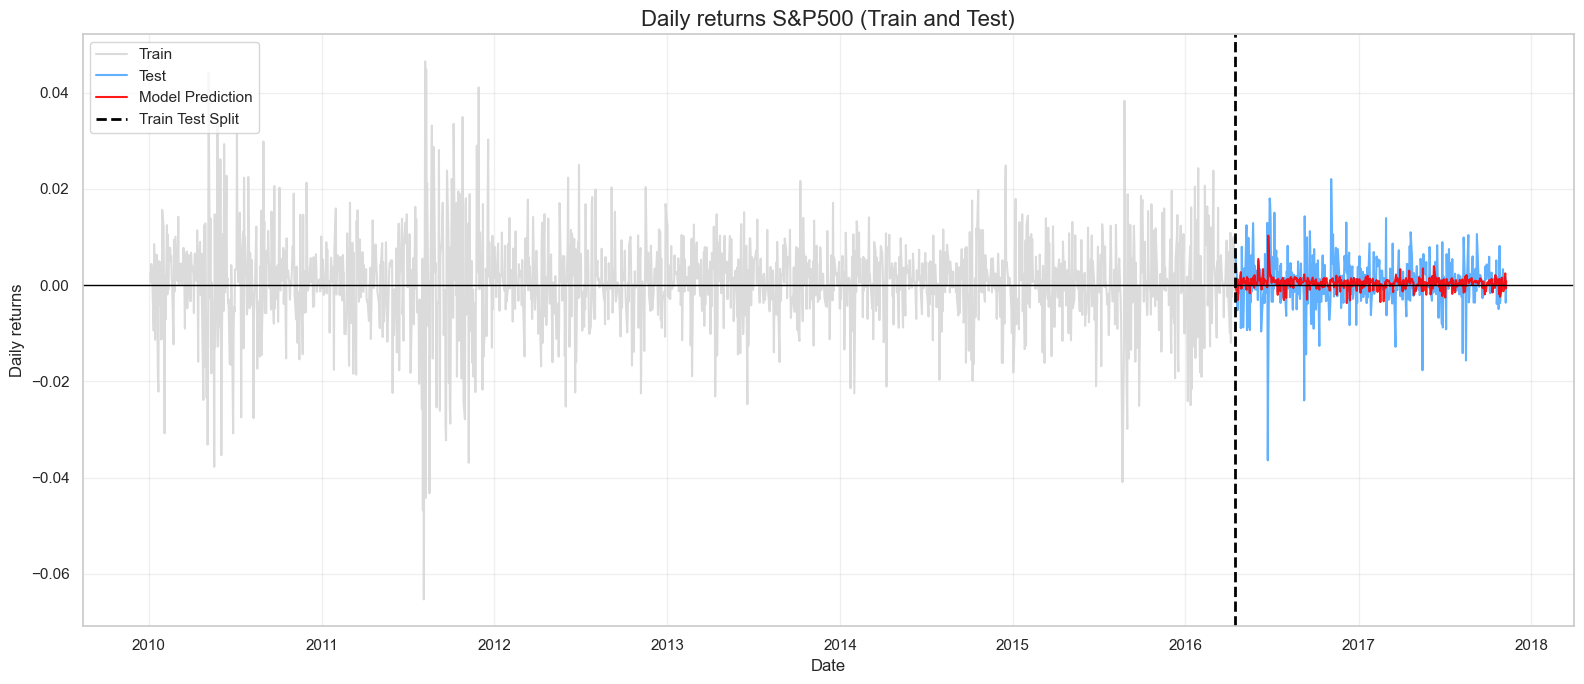

In [171]:
plt.figure(figsize=(16, 7))
plt.plot(y_train.index, y_train, label='Train', color='lightgray', alpha=0.8)
plt.plot(y_test.index, y_test, label='Test', color='dodgerblue', alpha=0.7)
plt.plot(y_test.index, y_pred, label='Model Prediction', color='red', alpha=0.9, linewidth=1.5)
plt.axvline(x=y_test.index[0], color='black', linestyle='--', linewidth=2, label='Train Test Split')
plt.axhline(0, color='black', linewidth=1)
plt.title('Daily returns S&P500 (Train and Test)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily returns', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [172]:
SEQ_LEN = 10 

X_values = X.values  
y_values = y.values

X_seq = []
y_seq = []

for i in range(len(X_values) - SEQ_LEN):
    window_X = X_values[i : i + SEQ_LEN]
    target_y = y_values[i + SEQ_LEN]
    
    X_seq.append(window_X)
    y_seq.append(target_y)

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq, y_seq, 
    test_size=0.2, 
    shuffle=False 
)

In [173]:
dates_seq = y.index[SEQ_LEN:]  # one date per target in y_seq
_, dates_test_seq = train_test_split(dates_seq, test_size=0.2, shuffle=False)

In [174]:
X_train_t = torch.tensor(X_train_seq, dtype=torch.float32)
y_train_t = torch.tensor(y_train_seq, dtype=torch.float32)
X_test_t = torch.tensor(X_test_seq, dtype=torch.float32)
y_test_t = torch.tensor(y_test_seq, dtype=torch.float32)

BATCH_SIZE = 32

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False) 

test_dataset = TensorDataset(X_test_t, y_test_t)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [175]:
class StockTransformer(nn.Module):
    def __init__(self, num_features, d_model=64, nhead=4, num_layers=2):
        super(StockTransformer, self).__init__()
        
        self.input_layer = nn.Linear(num_features, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=nhead, 
            batch_first=True,
            dim_feedforward=128,
            dropout=0.1
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output_layer = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.input_layer(x) 
        x = self.transformer_encoder(x) 
        x = x[:, -1, :] 
        out = self.output_layer(x)
        return out.squeeze()
num_features = X_train_seq.shape[2] 
model = StockTransformer(num_features=num_features)
print(model)

StockTransformer(
  (input_layer): Linear(in_features=12, out_features=64, bias=True)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (output_layer): Linear(in_features=64, out_features=1, bias=True)
)


In [176]:
from sklearn.preprocessing import StandardScaler

samples_train, seq_len, features = X_train_seq.shape
X_train_2d = X_train_seq.reshape(-1, features)

samples_test, _, _ = X_test_seq.shape
X_test_2d = X_test_seq.reshape(-1, features)

scaler = StandardScaler()
X_train_scaled_2d = scaler.fit_transform(X_train_2d)
X_test_scaled_2d = scaler.transform(X_test_2d)

X_train_seq_scaled = X_train_scaled_2d.reshape(samples_train, seq_len, features)
X_test_seq_scaled = X_test_scaled_2d.reshape(samples_test, seq_len, features)

X_train_t = torch.tensor(X_train_seq_scaled, dtype=torch.float32)
X_test_t = torch.tensor(X_test_seq_scaled, dtype=torch.float32)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False) 

test_dataset = TensorDataset(X_test_t, y_test_t)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [177]:
model = StockTransformer(num_features=features)

criterion = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

EPOCHS = 200

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        
    avg_loss = epoch_loss / len(train_loader)
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch + 1}/{EPOCHS}] | Average Training Loss: {avg_loss:.6f}")

Epoch [1/200] | Average Training Loss: 0.304078
Epoch [10/200] | Average Training Loss: 0.060632
Epoch [20/200] | Average Training Loss: 0.038479
Epoch [30/200] | Average Training Loss: 0.023994
Epoch [40/200] | Average Training Loss: 0.017464
Epoch [50/200] | Average Training Loss: 0.014646
Epoch [60/200] | Average Training Loss: 0.012185
Epoch [70/200] | Average Training Loss: 0.010838
Epoch [80/200] | Average Training Loss: 0.009930
Epoch [90/200] | Average Training Loss: 0.009265
Epoch [100/200] | Average Training Loss: 0.008557
Epoch [110/200] | Average Training Loss: 0.008386
Epoch [120/200] | Average Training Loss: 0.008048
Epoch [130/200] | Average Training Loss: 0.007728
Epoch [140/200] | Average Training Loss: 0.007602
Epoch [150/200] | Average Training Loss: 0.007418
Epoch [160/200] | Average Training Loss: 0.007311
Epoch [170/200] | Average Training Loss: 0.007108
Epoch [180/200] | Average Training Loss: 0.006925
Epoch [190/200] | Average Training Loss: 0.006989
Epoch [200/

In [178]:
mae_criterion = nn.L1Loss()
model.eval()
test_mae = 0.0

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        predictions = model(batch_X)
        mae = mae_criterion(predictions, batch_y)
        test_mae += mae.item()

avg_test_mae = test_mae / len(test_loader)
print(f"Test MAE: {avg_test_mae:.6f}")

Test MAE: 0.003804


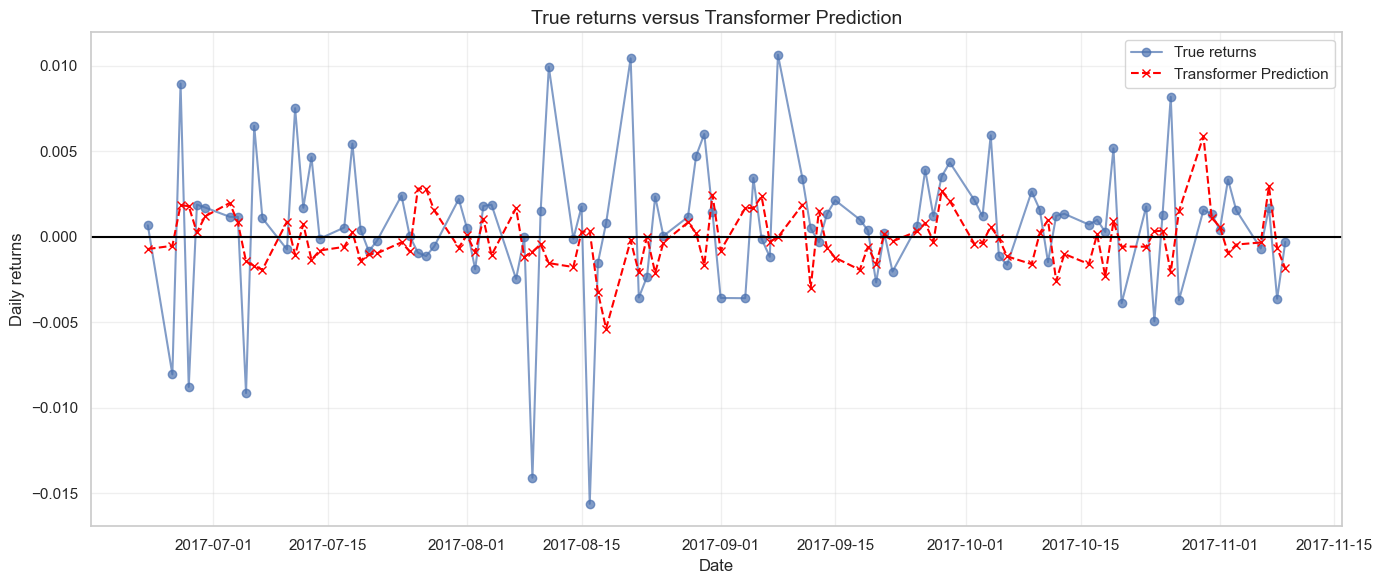

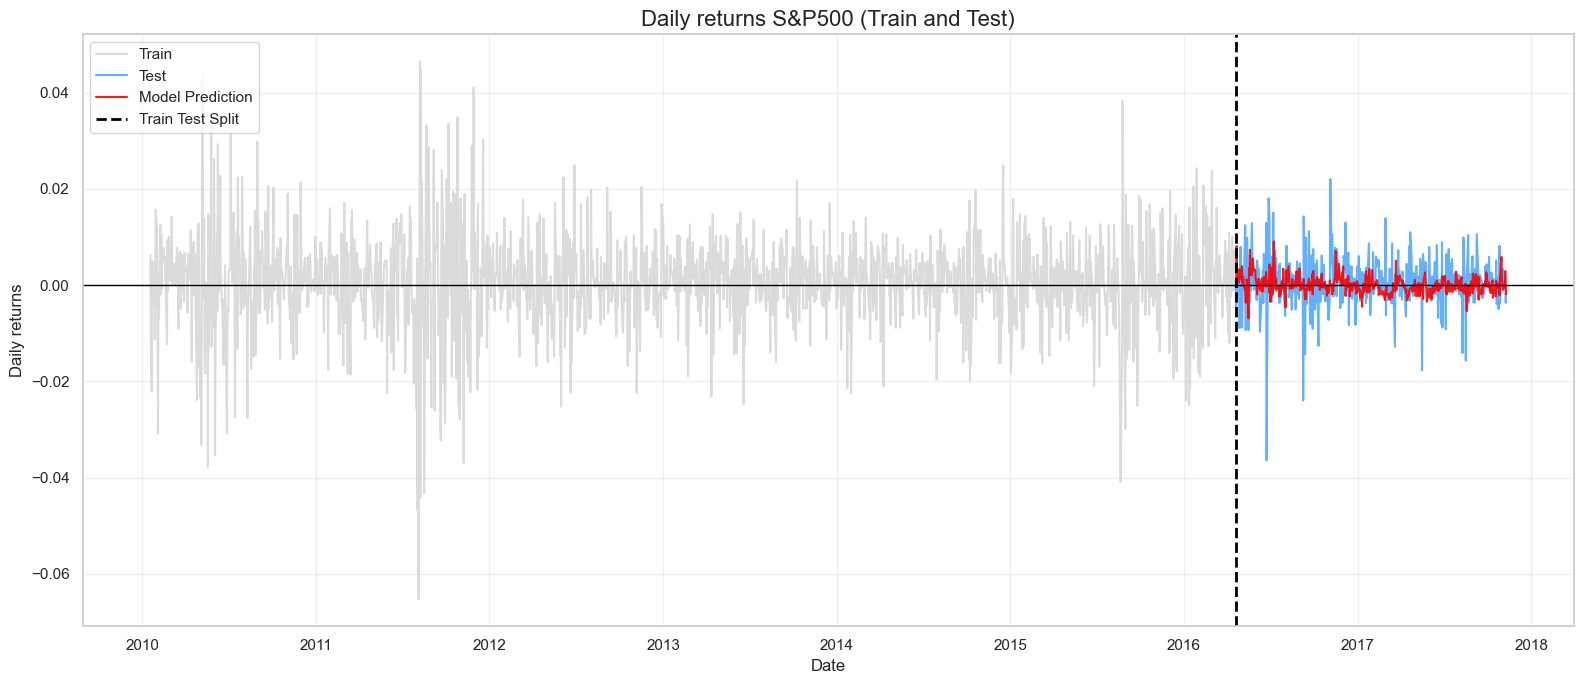

In [179]:
model.eval()
all_predictions = []
all_actuals = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        preds = model(batch_X)
        all_predictions.extend(preds.numpy())
        all_actuals.extend(batch_y.numpy())

all_predictions = np.array(all_predictions)
all_actuals = np.array(all_actuals)

# Plot 1 — last 100 days (matches XGB/LGB style)
plt.figure(figsize=(14, 6))
last_days = 100
plt.plot(dates_test_seq[-last_days:], all_actuals[-last_days:],
         label='True returns', marker='o', alpha=0.7)
plt.plot(dates_test_seq[-last_days:], all_predictions[-last_days:],
         label='Transformer Prediction', marker='x', linestyle='--', color='red')
plt.title('True returns versus Transformer Prediction', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily returns', fontsize=12)
plt.axhline(0, color='black', linewidth=1.5, linestyle='-')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2 — full train/test view (matches XGB/LGB style)
train_dates_seq = y.index[SEQ_LEN: SEQ_LEN + len(y_train_seq)]
plt.figure(figsize=(16, 7))
plt.plot(train_dates_seq, y_train_seq, label='Train', color='lightgray', alpha=0.8)
plt.plot(dates_test_seq, all_actuals, label='Test', color='dodgerblue', alpha=0.7)
plt.plot(dates_test_seq, all_predictions, label='Model Prediction', color='red', alpha=0.9, linewidth=1.5)
plt.axvline(x=dates_test_seq[0], color='black', linestyle='--', linewidth=2, label='Train Test Split')
plt.axhline(0, color='black', linewidth=1)
plt.title('Daily returns S&P500 (Train and Test)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily returns', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()